# Multidimensional Arrays in `numpy` and `matplotlib`

Before we begin to think about $n$-dimensional climate data, it is worth thinking about 2-D and 3-D data in formats we already know: specifically, `numpy` and `matplotlib`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Conceptualising and Visualising 2-D arrays

Let's create a simple 10 $\times$ 10 array:

In [13]:
# simple 10 x 10 array with zero values
array = np.zeros((10, 10))

# Use slicing to set interior values to increasingly high values
array[1:9, 1:9] = 1
array[2:8, 2:8] = 2
array[3:7, 3:7] = 3
array[4:6, 4:6] = 4

array

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [0., 1., 2., 2., 2., 2., 2., 2., 1., 0.],
       [0., 1., 2., 3., 3., 3., 3., 2., 1., 0.],
       [0., 1., 2., 3., 4., 4., 3., 2., 1., 0.],
       [0., 1., 2., 3., 4., 4., 3., 2., 1., 0.],
       [0., 1., 2., 3., 3., 3., 3., 2., 1., 0.],
       [0., 1., 2., 2., 2., 2., 2., 2., 1., 0.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Recall how we can use _indexing_ and _slicing_ to select and set values within lists and arrays: here, we are using 2-D slicing to set the inner values of the array to increasingly high values.

This might be a grid of numbers, but for our purposes as geospatial data, it could be whatever we wanted: for instance, these values might represent height values of a hill in a digital elevation model (DEM). In optical satellite data, values from from 0-1 often represent the _reflectance_ of a surface in a given wavelength (e.g. blue, short-wave infrared, etc.).

As a result, it might make sense to plot these data. Previously, we have been using `matplotlib` functions such as `plot` or `scatter`: for 2-D data, we can choose to plot using `imshow`:

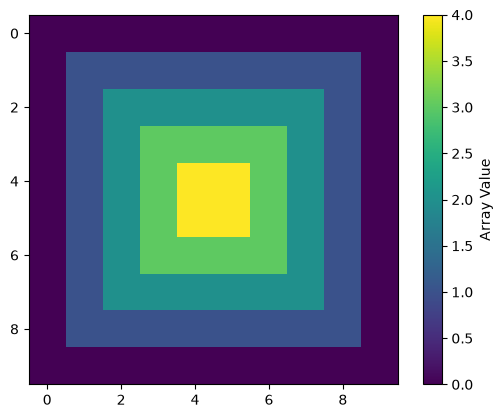

In [47]:
fig, ax = plt.subplots()

im = ax.imshow(array)

# to add a colorbar in 'pure' matplotlib, we can use the colorbar() function 
# and pass in the image variable and the axis object

plt.colorbar(im, ax=ax, label='Array Value')

plt.show()

By default, a numpy array will count _down_ the `y` axis and _up_ the `x` axis (this is opposite to geospatial data). It will present in the `viridis` `colormap` by default, which we discussed briefly last week (see colormaps on [this page](https://matplotlib.org/stable/users/explain/colors/colormaps.html)).

We can take advantage of additional `matpotlib` capability to assign realistic Northings and Eastings, as well as a `colormap` that might indicate that this is a surface DEM.

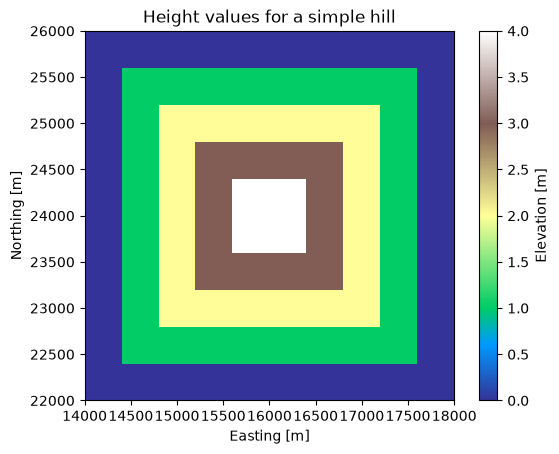

In [38]:
# generate X and Y coordinates in hypothetical Easting and Northing [m] values
x = np.linspace(14000, 18000, 10)  # 10 values between 14000 and 18000
y = np.linspace(22000, 26000, 10)  # 10 values between 22000 and 26000


# Set an extent for the image using the min and max values of x and y
extent = [x.min(), x.max(), y.min(), y.max()]

fig, ax = plt.subplots()

im = ax.imshow(
    array, 
    extent=extent,
    cmap='terrain',
    )

plt.colorbar(im, ax=ax, label='Elevation [m]')

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')

ax.set_title('Height values for a simple hill')

plt.show()


Note that we did something slightly different to set the `x` and `y` axis labels in this example. `plt.imshow()` doesn't accept simple 1-D lists/arrays of `x` and `y` coordinates for axes: it wants an '`extent`' which is a list of `[xmin, xmax, ymin, ymax]` values (note this is a different convention to geospatial 'bounds', which are ordered `[xmin, ymin, xmax, ymax]`). 

In other instances of plotting, you may require a different format again, with rectangular grids indicating the `x` and `y` coordinates across the array. This can be produced automatically using the `numpy` `meshgrid()` function, which produces these outputs (known as _coordinate matrices_) from 1-D coordinate inputs, as below: 

In [44]:
X, Y = np.meshgrid(x, y)  # create a meshgrid of X and Y coordinates

The `X` and `Y` arrays are 2-D arrays containing the X and Y coordinate values across the grid:

Text(0.5, 1.0, 'Y values (Northing)')

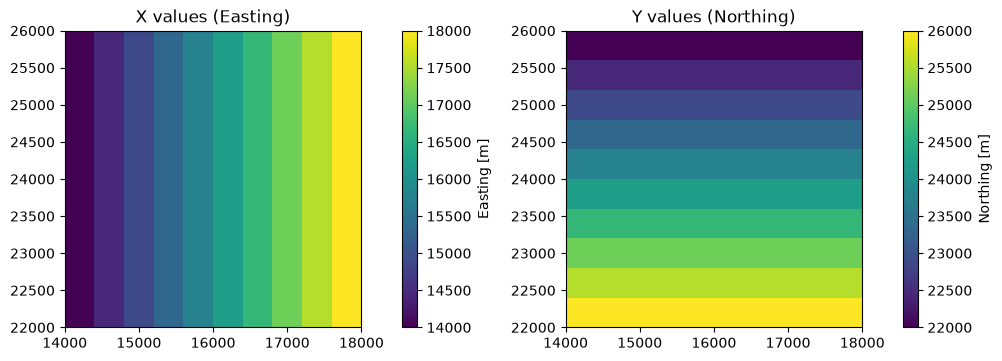

In [43]:
fig, axes  = plt.subplots(ncols=2, figsize=(10, 3.5), layout='constrained')

ax = axes[0]
im = ax.imshow(X, extent=extent)
plt.colorbar(im, ax=ax, label='Easting [m]')
ax.set_title('X (Easting) grid')

ax = axes[1]
im = ax.imshow(Y, extent=extent)
plt.colorbar(im, ax=ax, label='Northing [m]')
ax.set_title('Y (Northing) grid')

plt.show()

This is required for certain alternative visualisations. For instance, we could try and plot this as a 3-D surface, where the position on the `z` axis is determined by the value in the array. This uses the `plot_surface` function, and requires `X` and `Y` coordinate matrices as inputs alongside a `z` grid:

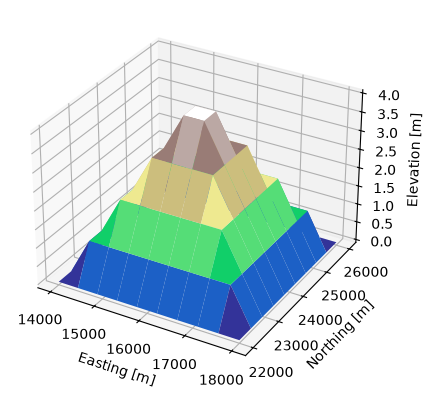

In [39]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

ax.plot_surface(
    X,
    Y,
    array,
    cmap='terrain',
    edgecolor='none',
    )

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_zlabel('Elevation [m]')

plt.show()

## Conceptualising and Visualising 3-D arrays

Numpy arrays can go further, into three (and more!) dimensions. In the lecture, we thought about what having more than one 2-D layer might mean: whilst our default two dimensions are probably `x` and `y`, having an additional dimension could mean an number of things, including height, time, or bands of a satellite. 

A simple 3-D array might look as follows:

In [34]:
# use np.random.rand() to generate a simple 3D array with the shape (5, 5, 3) and random values between 0 and 1.
simple_3d_array = np.random.rand(5, 5, 3)

simple_3d_array

array([[[0.79903079, 0.04620872, 0.94744186],
        [0.60745678, 0.36699266, 0.88861438],
        [0.77332849, 0.73350582, 0.04755945],
        [0.89437654, 0.06892082, 0.87849206],
        [0.350513  , 0.75657868, 0.38675859]],

       [[0.44813642, 0.36318579, 0.45553713],
        [0.02392158, 0.91112118, 0.0732385 ],
        [0.83278774, 0.34623621, 0.67793849],
        [0.60652585, 0.39723117, 0.51962739],
        [0.90601567, 0.02573587, 0.04202075]],

       [[0.1377354 , 0.66296205, 0.96370304],
        [0.33913663, 0.79976465, 0.81311981],
        [0.54614346, 0.25510057, 0.22007475],
        [0.94027566, 0.13166177, 0.85819398],
        [0.01669832, 0.49188612, 0.32461667]],

       [[0.62287661, 0.80648353, 0.60720776],
        [0.10945618, 0.23786609, 0.82547149],
        [0.28208895, 0.19294521, 0.41895188],
        [0.57874911, 0.75031904, 0.02851867],
        [0.04432798, 0.76702646, 0.65760737]],

       [[0.28243195, 0.81205885, 0.54038259],
        [0.37466708, 0.870

Even with this small shape, it is becoming increasingly hard to visualise: additional dimensions are represented as arrays within arrays, and nested square brackets aren't easy to parse! 

For now, though, let's create a slightly larger 3-D array with consistent patterns in each layer of the `z` axis, to show how me might think about visualising this data.

In [51]:
# Create spatial coordinate grids from -1 to 1 for a 50x50 array
coords = np.linspace(-1, 1, 50)
X, Y = np.meshgrid(coords, coords)

# First z index: Horizontal Gradient (0 on left, 1 on right)
z0 = (X + 1) / 2

# Second z index: Vertical Parabola (1 in center, 0 at top/bottom edges)
z1 = 1 - Y**2

# Third z index: Circular Distance (1 at center, fading to 0 at edges)
distance = np.sqrt(X**2 + Y**2)
z2 = np.maximum(0, 1 - distance)

# Stack bands along the 3rd axis to form numpy array with shape (50, 50, 3)
example_3d_array = np.dstack((z0, z1, z2))

print("Shape of the 3D array:", example_3d_array.shape)

Shape of the 3D array: (50, 50, 3)


If we again assume that the first two axes are `x` and `y`, the third axis could be time, `t`, with the array representing how a value is changing through time. For example:

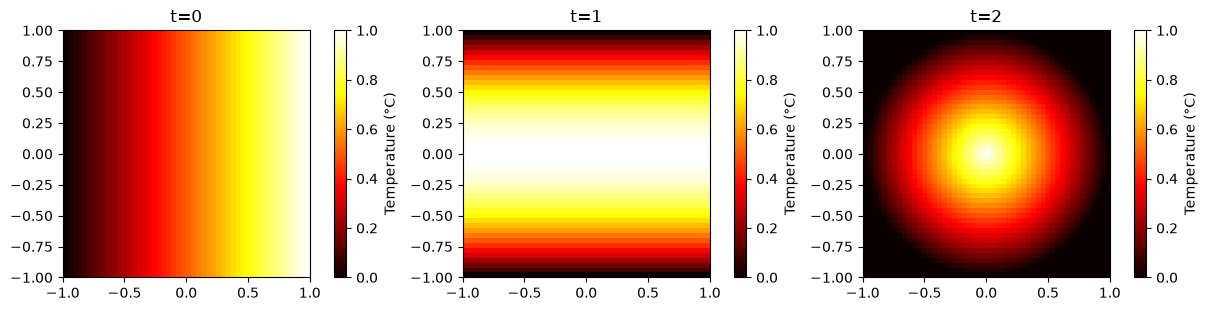

In [54]:
# plot three slices of example_3d_array as a 1x3 grid of subplots, with temperature colormaps for each slice

fig, axes = plt.subplots(ncols=3, figsize=(12, 3), layout='constrained')

ax = axes[0]
im = ax.imshow(example_3d_array[:, :, 0], cmap='hot', extent=[-1, 1, -1, 1], vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Temperature (°C)')
ax.set_title('t=0')

ax = axes[1]
im = ax.imshow(example_3d_array[:, :, 1], cmap='hot', extent=[-1, 1, -1, 1], vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Temperature (°C)')
ax.set_title('t=1')

ax = axes[2]
im = ax.imshow(example_3d_array[:, :, 2], cmap='hot', extent=[-1, 1, -1, 1], vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Temperature (°C)')
ax.set_title('t=2')

plt.show()

However, for optical satellite data, the `z` axis often doesn't represent a single continuous value such as height, but instead discrete 'bands' (e.g. red, blue, green, near infra-red, short-wave infra-red, etc...). In this case, a useful `matplotlib` function is `plt.imshow()`. This will accept a 3-D array and assume that each of the three bands relates to (in order) the intensity of the red, green, and blue channels:

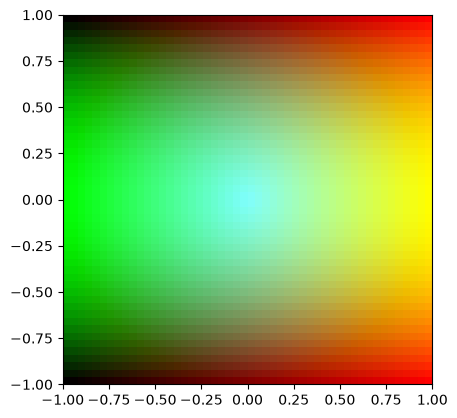

In [59]:
# plt.imshow

fig, ax = plt.subplots()

ax.imshow(example_3d_array, extent=[-1, 1, -1, 1])

plt.show()

The function assumes that the `z` index is ordered red-green-blue, and that the scale either goes from `0` to `1`, or from `0` to `255` (i.e. 8-bit imagery). 

Next week, we will think about _false-colour_ imagery, where we swap what data is represented in each of the RGB channels to highlight different aspects of the data.



## Summary

We have begun to think about what sort of geospatial data might be included in 2-D and 3-D data, and how we can begin to plot this. We are beginning to see the cracks in this approach: it is becoming hard to keep track of what values and coordinates represent. It would be nice to supplement a `numpy` array with additional functionality to help us properly label coordinates/axes, much like `pandas` did for tabular data. We will do this in the next section by beginning to use `xarray`.